In [1]:
import sys
sys.path.insert(1, '../scripts')

import zarr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from MAST_utils.store import MASTStoreManager, plot_1d_profile, plot_1d_profiles


In [2]:
store_manager = MASTStoreManager()

In [ ]:
all_shots_ids = store_manager.list_all_shots(local=False)
all_shots_ids


In [ ]:
all_sources = store_manager.list_all_sources(shot_id=30471, as_data_frame=False)  # all_shots_ids[0])
try:
    print(all_sources.to_string())
    print(all_sources.keys())
except:
    print(all_sources)


In [ ]:
all_signals = store_manager.list_all_signals(shot_id=30471, as_data_frame=False)
try:
    print(all_signals.to_string())
except:
    print(all_signals)


In [3]:
group_ = store_manager.make_shot_group(shot_id=30421, local=False, verbose=False)
# group_

signals = list(group_["summary"].keys())
signal = signals[6]

profiles = xr.open_zarr(group_.store, group='summary')


C:\Users\I85464754\OneDrive - IBM\01 Current Work\01 Fusion and Heliophysics\02 Repos\02 GitLab\fairmast-data-preprocessing\notebooks\../scripts\MAST_utils\store.py:435: UserWarning: WARNING: This method misbehaves if not run in a notebook cell with `%matplotlib notebook` header.
  warnings.warn("WARNING: This method misbehaves if not run in a notebook cell with `%matplotlib notebook` header.")


<IPython.core.display.Javascript object>


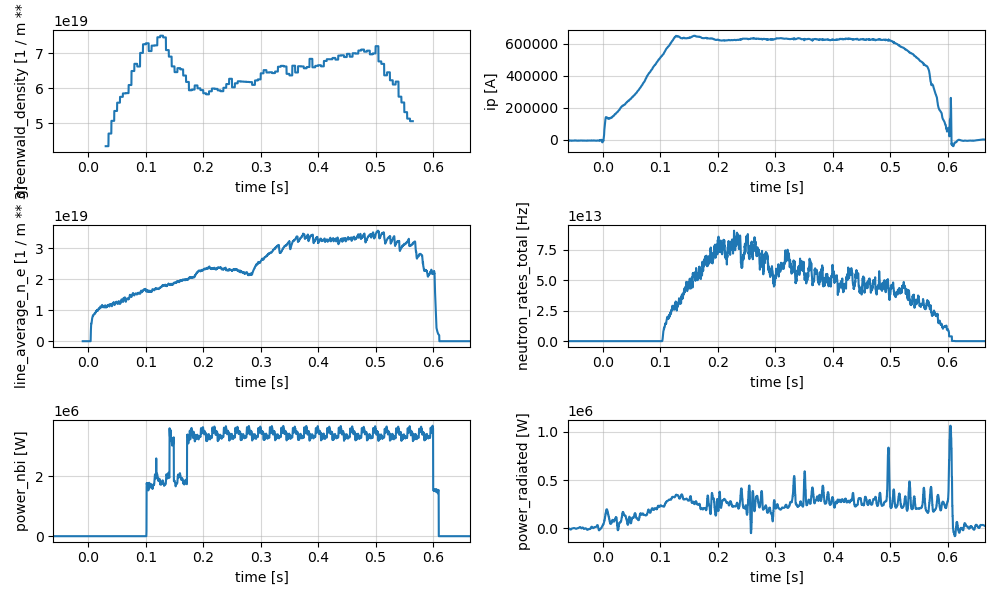

In [4]:
%matplotlib notebook

# plot_1d_profile(profiles[signal])
plot_1d_profiles(profiles)


In [ ]:
store_ = group_.store
# for ii in group_:
#     print(list(group_[ii].keys()))
    
vars(store_)

In [7]:
import pkg_resources

dists = [str(d).replace(" ","==") for d in pkg_resources.working_set]
dists.sort()
for i in dists:
    print(i)


Brotli==1.1.0
Deprecated==1.2.18
MarkupSafe==3.0.2
PySide6==6.8.3
PySocks==1.7.1
PyYAML==6.0.2
Send2Trash==1.8.3
aiobotocore==2.21.1
aiohappyeyeballs==2.6.1
aiohttp==3.11.18
aioitertools==0.12.0
aiosignal==1.3.2
anyio==4.9.0
argon2-cffi-bindings==21.2.0
argon2-cffi==23.1.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
autocommand==2.2.2
babel==2.17.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
black==25.1.0
bleach==6.2.0
botocore==1.37.1
cached-property==1.5.2
certifi==2025.1.31
cffi==1.17.1
charset-normalizer==3.4.1
click==8.1.8
colorama==0.4.6
comm==0.2.2
contourpy==1.3.2
crc32c==2.7.1
cycler==0.12.1
debugpy==1.8.14
decorator==5.2.1
defusedxml==0.7.1
donfig==0.8.1.post1
exceptiongroup==1.2.2
executing==2.2.0
fastjsonschema==2.21.1
fonttools==4.57.0
fqdn==1.5.1
frozenlist==1.5.0
fsspec==2025.3.0
h11==0.16.0
h2==4.2.0
hpack==4.1.0
httpcore==1.0.9
httpx==0.28.1
hyperframe==6.1.0
idna==3.10
importlib-metadata==8.6.1
importlib-resources==6.5.2
inflect==7.3.1
ipykernel==

C:\Users\I85464754\AppData\Local\Temp\ipykernel_45892\2466207844.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
import fsspec
import zarr.storage

shot_id=30471
endpoint_url = 'https://s3.echo.stfc.ac.uk'
url = f'/mast/test/level2/shots/{shot_id}.zarr'

fs = fsspec.filesystem(
    **dict(
        protocol='simplecache',
        target_protocol="s3",
        target_options=dict(anon=True, endpoint_url=endpoint_url)
    )
)
# store = zarr.storage.FsspecStore(fs=fs, path=url)

In [ ]:
# for ii in store:
#     print(ii)

len(store_manager.list_all_shots(local=False))

In [ ]:
group_ = store_manager.open_group(shot_id=30421, local=False, verbose=False)
vars(group_.store.fs)

In [ ]:
# import s3fs

# shot_id=30471
# root_ = f'/mast/test/level2/shots/{shot_id}.zarr'

s3_ = s3fs.S3FileSystem(
    anon=True,
    endpoint_url="https://s3.echo.stfc.ac.uk",
    asynchronous=True
)

# store = s3fs.S3Map(s3=s3_, root=root_)
# cache = zarr.LRUStoreCache(store)

store = zarr.storage.FsspecStore(
    fs=s3_,
    read_only=True,
    path='/mast/level2/shots/30471.zarr',
#     storage_options={'anon': True}
)

gg = zarr.open_group(store=store, mode='r')


In [6]:
import asyncio
asyncio.__version__
# type(zarr.storage.FsspecStore)

AttributeError: module 'asyncio' has no attribute '__version__'

In [ ]:
# zarr.storage.FsspecStore()
isinstance(store, zarr.storage.FsspecStore)

In [9]:
help(zarr.open_group)

Help on function open_group in module zarr.api.synchronous:

open_group(store: 'StoreLike | None' = None, *, mode: 'AccessModeLiteral' = 'a', cache_attrs: 'bool | None' = None, synchronizer: 'Any' = None, path: 'str | None' = None, chunk_store: 'StoreLike | None' = None, storage_options: 'dict[str, Any] | None' = None, zarr_version: 'ZarrFormat | None' = None, zarr_format: 'ZarrFormat | None' = None, meta_array: 'Any | None' = None, attributes: 'dict[str, JSON] | None' = None, use_consolidated: 'bool | str | None' = None) -> 'Group'
    Open a group using file-mode-like semantics.
    
    Parameters
    ----------
    store : Store, str, or mapping, optional
        Store or path to directory in file system or name of zip file.
    
        Strings are interpreted as paths on the local file system
        and used as the ``root`` argument to :class:`zarr.storage.LocalStore`.
    
        Dictionaries are used as the ``store_dict`` argument in
        :class:`zarr.storage.MemoryStore``